In [38]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [39]:
def drop_desc(df):
    ''' Elimina le colonne descrittive.
        Parametri: 
            df: DataFrame da elaborare 
        Restituisce il DataFrame elaborato
    '''
    desc_cols = [c for c in df.columns if c.startswith("DESC_")]
    return df.drop(columns=desc_cols, errors="ignore")

In [40]:
def clean_date(df, col, min_date, max_date):
    ''' Converte le colonne in formato leggibile e sostituisce i valori fuori dall' intervallo (min_date,max_date)
        con la mediana delle date.
        Parametri:
            df: DataFrame da elaborare
            col: colonne da elaborare (colonne con date)
            min_date,max_date: data minima e massima
        Restituisce:
            d: DataFrame elaborato
    '''
    d = pd.to_datetime(df[col], format="%Y%m%d", errors="coerce")
    mask = (d < min_date) | (d > max_date)
    d[mask] = pd.NaT
    d = d.fillna(d.median())
    return d

In [41]:
def drop_rare_dummies_train_test(x_train, x_test, min_count=3):
    ''' Rimuove dal dataset di training e di test le colonne in cui vi sono meno "valori veri" di "min_count".
        Parametri:
            x_train: l' input del modello per il training.
            x_test: l' input del modello per il test.
            min_count: (default 3) Il numero minimo di valori "veri".
    '''
    # colonne dummy = uint8 
    rare_cols = [
        col for col in x_train.columns
        if (x_train[col].dtype in ["bool"]) and (x_train[col].sum() < min_count)
    ]
    
    # rimuovo SOLO dal train
    x_train = x_train.drop(columns=rare_cols)
    
    # rimuovo le stesse colonne dal test (se presenti)
    x_test = x_test.drop(columns=[c for c in rare_cols if c in x_test.columns])
    
    return x_train, x_test, rare_cols

In [42]:
def print_matrix(df):
    ''' Stampa la matrice di correlazione del dataframe.'''
    matrix = df.corr(numeric_only=True)
    plt.figure()
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.show()

In [43]:
def prepare_features(df):
    ''' Prepara le features per il modello di ML.'''
    df = df.copy()

    # -----------------------------
    # 0. RIMOZIONE COLONNE STRETTAMENTE CORRELATE E IENTIFICATIVI UNIVOCI ORDINE
    # -----------------------------
    df = df.drop(columns=["ID_ORDER_NUM", "VAL_COST"], errors="ignore")

    # -----------------------------
    # 1. ONE-HOT ENCODING
    # -----------------------------
    categorical_cols = [
        "ID_COMPANY", "IDS_ITEM", "ID_BUSINESS_LINE",
        "IDS_CUSTOMER", "ID_AREA_MANAGER", "ID_COUNTRY"
    ]

    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # -----------------------------
    # 2. RIMOZIONE COLONNE TESTUALI
    # -----------------------------
    df = drop_desc(df)

    # -----------------------------
    # 3. FEATURE TEMPORALI
    # -----------------------------
    df["ANNO"] = df["ID_ORDER_DATE"].dt.year
    df["TRIMESTRE"] = df["ID_ORDER_DATE"].dt.quarter
    df["MESE"] = df["ID_ORDER_DATE"].dt.month
    df["MESE_SIN"] = np.sin(2 * np.pi * df["ID_ORDER_DATE"].dt.month / 12)
    df["MESE_COS"] = np.cos(2 * np.pi * df["ID_ORDER_DATE"].dt.month / 12)

    df["SETTIMANA"] = df["ID_ORDER_DATE"].dt.isocalendar().week.astype(int)
    df["GIORNO_SETTIMANA"] = df["ID_ORDER_DATE"].dt.weekday
    df["GIORNO_SETTIMANA_SIN"] = np.sin(2 * np.pi * df["ID_ORDER_DATE"].dt.weekday / 7)
    df["GIORNO_SETTIMANA_COS"] = np.cos(2 * np.pi * df["ID_ORDER_DATE"].dt.weekday / 7)
    df["WEEKEND"] = df["GIORNO_SETTIMANA"].isin([5,6]).astype(int)

    df["GIORNO"] = df["ID_ORDER_DATE"].dt.dayofyear
    df["GIORNO_SIN"] = np.sin(2 * np.pi * df["GIORNO"] / 365)
    df["GIORNO_COS"] = np.cos(2 * np.pi * df["GIORNO"] / 365)

    # -----------------------------
    # 4. RIMOZIONE DATE ORIGINALI
    # -----------------------------
    df = df.drop(columns=["ID_ORDER_DATE", "ID_INVOICE_DATE"], errors="ignore")

    return df

In [44]:
def make_forecast(start_date, end_date, df_old):
    """
    Genera forecast solo per le combinazioni cliente-item esistenti nello storico.
    e applica le feature temporali tramite prepare_features().
    NON allinea le colonne con il train.
    """

    # -----------------------------
    # 1. GENERO IL CALENDARIO FUTURO
    # -----------------------------
    future_dates = pd.date_range(start=start_date, end=end_date, freq="D")
    df_future = pd.DataFrame({"ID_ORDER_DATE": future_dates})

    # -----------------------------
    # 2. Estraggo combinazioni reali cliente-item-company-line-area-country
    # -----------------------------
    dims = df_old[[
        "ID_COMPANY",
        "IDS_ITEM",
        "ID_BUSINESS_LINE",
        "IDS_CUSTOMER",
        "ID_AREA_MANAGER",
        "ID_COUNTRY"
    ]].drop_duplicates()

    df_future = df_future.merge(dims, how="cross")

    # -----------------------------
    # 3. APPLICO LE FEATURE (prepare_features)
    # -----------------------------
    df_future = prepare_features(df_future)

    # -----------------------------
    # 4. RESTITUISCO IL DATAFRAME FUTURO
    # -----------------------------
    return df_future

In [45]:
def plot_trend(df, revenue_col="VAL_REVENUES"):
    """
    Disegna l'andamento medio della revenue per mese.
    """

    df = df.copy()

    # Media per mese
    trend = df.groupby("MESE")[revenue_col].mean().reset_index()

    plt.figure(figsize=(12,5))
    plt.plot(trend["MESE"], trend[revenue_col], marker="o", linewidth=2)

    # Etichette mese (01..12)
    plt.xticks(ticks=trend["MESE"], labels=trend["MESE"].astype(str).str.zfill(2))

    plt.title("Andamento medio mensile della revenue")
    plt.xlabel("Mese")
    plt.ylabel("Revenue media")
    plt.show()

# -----------------------------
# 1. CARICAMENTO E MERGE DATI
# -----------------------------

In [46]:
df_sales = pd.read_csv("SALES.csv")
df_company = pd.read_csv("COMPANY_LOOKUP.csv").drop_duplicates()
df_items = pd.read_csv("ITEM_LOOKUP.csv").drop_duplicates()
df_lines = pd.read_csv("ITEM_BUSINESS_LINE_LOOKUP.csv").drop_duplicates()
df_customers = pd.read_csv("CUSTOMER_LOOKUP.csv").drop_duplicates()
df_area = pd.read_csv("AREA_MANAGER_LOOKUP.csv").drop_duplicates()

df = df_sales.merge(df_company, on="ID_COMPANY", how="left")
df = df.merge(df_items, on="IDS_ITEM", how="left")
df = df.merge(df_lines, on="ID_BUSINESS_LINE", how="left")
df = df.merge(df_customers, on="IDS_CUSTOMER", how="left")
df = df.merge(df_area, on="ID_AREA_MANAGER", how="left")

# -----------------------------
# 2. PULIZIA DATE
# -----------------------------

In [47]:
min_date = pd.Timestamp("1900-01-01")
max_date = pd.Timestamp("today")

df["ID_INVOICE_DATE"] = clean_date(df, "ID_INVOICE_DATE", min_date, max_date)
df["ID_ORDER_DATE"] = clean_date(df, "ID_ORDER_DATE",   min_date, max_date)

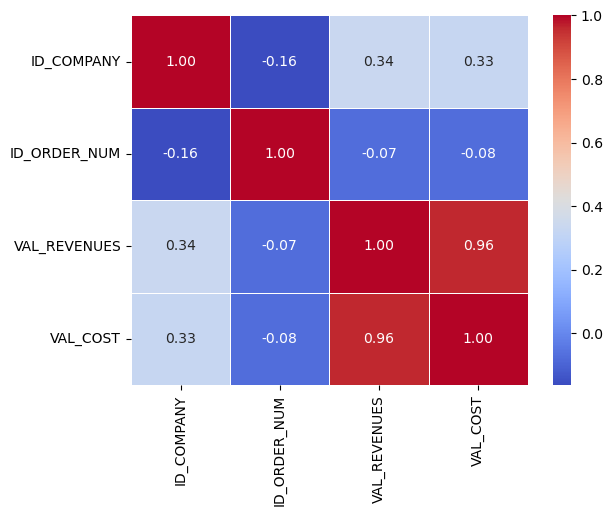

In [48]:
df.to_csv("SALES_OLAP.csv")
print_matrix(df)